# E21 · When the network is the data: latent-space and stochastic block models

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Lazega (2001): the strong-coworker network among the 71 lawyers (36 partners, 35 associates) of a New England corporate law firm, with office, practice, status, gender, law school and seniority of every lawyer |
| **You will learn** | Why the 2485 dyads of a 71-node graph are not 2485 independent observations · dyad logistic regression with homophily covariates, and what it gets wrong · sociality (degree-heterogeneity) random effects · Hoff's latent-space model, its rotation / reflection / translation invariance, the r_hat it produces, and Procrustes post-processing · latent maps with uncertainty · stochastic block models: why node memberships cannot be summed out, the mixed-membership SBM whose dyad-level memberships can (a `logsumexp` over $K^2$ block pairs) · label switching and the co-clustering matrix · why a block model without degree correction finds the wrong blocks · posterior predictive checks on network statistics (degrees, triangles, shared partners, geodesics) · link prediction on held-out dyads and leave-one-dyad-out LOO |

In E18 the graph was *given* (which regions border which) and carried a spatial prior; in E19
the graph was *learned* from correlations between variables. Here the graph is the **data**:
each of the $\binom{71}{2} = 2485$ pairs of lawyers either worked together last year or did
not, and the question is what generated that pattern of ties.

The obvious first move - one row per pair, a logistic regression of "tie" on "same office",
"same practice" and so on - treats the 2485 pairs as independent. They are not: every lawyer
appears in 70 of them. A busy partner raises the tie probability of all 70 of her pairs at
once, and "two of my coworkers work together" is far more likely than chance. The models in
this notebook add that structure one piece at a time and check, with statistics that live
on the whole graph, which piece each model actually reproduces.

In [1]:
import logging
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import xarray as xr
from matplotlib.patches import Ellipse
from scipy.sparse.csgraph import shortest_path
from scipy import stats as sps
from scipy.special import expit
from scipy.stats import rankdata

from pymc_challenges import data

RANDOM_SEED = 1991
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # several fits: no banner each time
BLUE, ORANGE, AQUA, GREY, RED, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#c2185b", "#7b4fc9"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")


def draws(idata, name):
    """Posterior draws of one variable as a NumPy array with the samples first."""
    return idata.posterior[name].stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()


def report(idata, label, var_names, seconds):
    div = int(idata.sample_stats["diverging"].sum())
    rhat = max(float(az.rhat(idata, var_names=[v])[v].max()) for v in var_names)
    ess = min(float(az.ess(idata, var_names=[v])[v].min()) for v in var_names)
    print(f"{label:<28} {seconds:5.0f} s   divergences {div}   max r_hat {rhat:.3f}   "
          f"min bulk ESS {ess:.0f}   ({', '.join(var_names)})")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The firm and its network

Emmanuel Lazega spent 1988-1991 inside "SG&R", a corporate law firm with three offices, and
asked each of its 71 lawyers to tick, on a list of everyone in the firm, the colleagues they
had *worked with* over the past year (spent time on the same case, read or used each other's
work). The released matrix is symmetric: a tie is recorded when the pair worked together.
Lawyers 1-36 are partners, 37-71 associates. The attributes are the ones any organisational
sociologist would reach for: office, type of practice (litigation or corporate law), status,
gender, law school and years with the firm.

In [2]:
data.describe("lazega_cowork")
data.describe("lazega_attributes")
W = data.load("lazega_cowork").to_numpy()
att = data.load("lazega_attributes")
n = len(att)
att["office_name"] = att.office.map({1: "Boston", 2: "Hartford", 3: "Providence"})
att["practice_name"] = att.practice.map({1: "litigation", 2: "corporate"})
att["status_name"] = att.status.map({1: "partner", 2: "associate"})
assert W.shape == (n, n) and (W == W.T).all() and np.diag(W).sum() == 0
deg = W.sum(1)
att["degree"] = deg
pd.crosstab([att.office_name, att.practice_name], att.status_name, margins=True)

lazega_cowork: 71 x 71 symmetric 0/1 strong-coworker matrix (378 ties) among the firm's 36 partners (rows 1-36) and 35 associates, row i = lawyer i of `lazega_attributes`.
  source: Lazega (2001), The Collegial Phenomenon (Oxford UP): lawyers of a New England corporate law firm, 1988-1991; distributed by T. Snijders' SIENA data page (file ELwork.dat).
  url:    https://www.stats.ox.ac.uk/~snijders/siena/LazegaLawyers.zip
lazega_attributes: Attributes of the 71 lawyers: seniority rank, status (1 partner, 2 associate), gender (1 man, 2 woman), office (1 Boston, 2 Hartford, 3 Providence), years with the firm, age, practice (1 litigation, 2 corporate), law school (1 Harvard/Yale, 2 UConn, 3 other).
  source: Lazega (2001), via T. Snijders' SIENA data page (file ELattr.dat).
  url:    https://www.stats.ox.ac.uk/~snijders/siena/LazegaLawyers.zip


status_name                associate  partner  All
office_name practice_name                         
Boston      corporate              9       10   19
            litigation            17       12   29
Hartford    corporate              3        5    8
            litigation             3        8   11
Providence  corporate              2        1    3
            litigation             1        0    1
All                               35       36   71

Every pair of lawyers is a **dyad**. We store the upper triangle as three flat arrays - the
two lawyers `I`, `J` and the tie `y` - and build the dyad-level covariates the homophily story
needs: same office, same practice, same status, same gender, same law school, and the gap in
years with the firm (per decade).

In [3]:
I, J = np.triu_indices(n, 1)
y = W[I, J]


def same(col):
    v = att[col].to_numpy()
    return (v[I] == v[J]).astype(float)


X = np.column_stack([same("office"), same("practice"), same("status"), same("gender"), same("school"),
                     np.abs(att.years.to_numpy()[I] - att.years.to_numpy()[J]) / 10])
cov_names = ["same_office", "same_practice", "same_status", "same_gender", "same_school", "years_gap"]
print(f"{n} lawyers, {len(y)} dyads, {y.sum()} ties, density {y.mean():.3f}")
pd.DataFrame({"covariate": cov_names[:5],
              "tie rate if same": [y[X[:, k] == 1].mean().round(3) for k in range(5)],
              "tie rate if different": [y[X[:, k] == 0].mean().round(3) for k in range(5)]})

71 lawyers, 2485 dyads, 378 ties, density 0.152


,covariate,tie rate if same,tie rate if different
0,same_office,0.233,0.063
1,same_practice,0.238,0.064
2,same_status,0.126,0.178
3,same_gender,0.167,0.129
4,same_school,0.164,0.146


Homophily is strong: pairs in the same office work together nearly four times as often as
pairs in different offices, and the same holds for practice. The two are correlated (Hartford has
both practices, Providence is small), which is exactly what a regression is for.

Two descriptive facts make the dyads dependent. Sorting the adjacency matrix by office,
practice and status shows **blocks**: dense squares on the diagonal (people in the same
office and practice) and near-empty rectangles elsewhere. And the degrees - the number of
coworkers of each lawyer - range from 0 to 28, much wider than the Binomial(70, 0.15) spread
a graph of independent, equally likely ties would give.

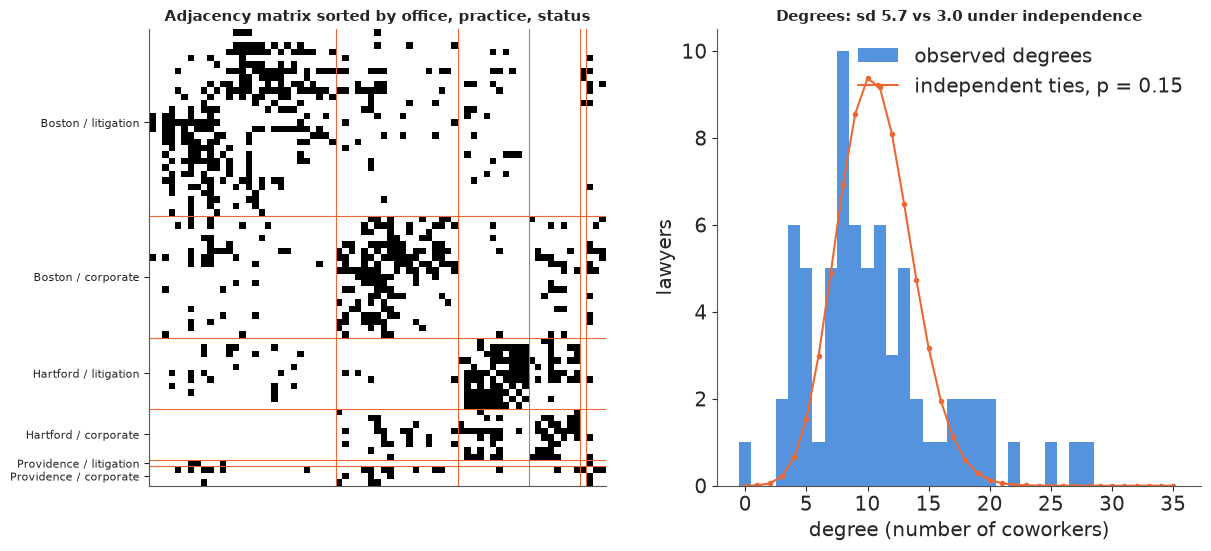

In [4]:
order = np.lexsort((att.status.to_numpy(), att.practice.to_numpy(), att.office.to_numpy()))
fig, axes = plt.subplots(1, 2, figsize=(12, 5.4), width_ratios=[1.1, 1])
ax = axes[0]
ax.imshow(W[np.ix_(order, order)], cmap="Greys", interpolation="nearest")
grp = (att.office_name + " / " + att.practice_name).to_numpy()[order]
cuts = np.flatnonzero(grp[1:] != grp[:-1]) + 0.5
for c in cuts:
    ax.axhline(c, color=ORANGE, lw=0.8)
    ax.axvline(c, color=ORANGE, lw=0.8)
starts = np.r_[0, np.ceil(cuts).astype(int)]
ends = np.r_[np.ceil(cuts).astype(int), n]
ax.set_yticks((starts + ends - 1) / 2)
ax.set_yticklabels([grp[s] for s in starts], fontsize=8)
ax.set_xticks([])
ax.set_title("Adjacency matrix sorted by office, practice, status", fontsize=11)
ax = axes[1]
p_hat = y.mean()
ks = np.arange(0, 36)
ax.hist(deg, bins=np.arange(-0.5, 36), color=BLUE, alpha=0.8, label="observed degrees")
ax.plot(ks, n * sps.binom(n - 1, p_hat).pmf(ks), "o-", color=ORANGE, ms=3,
        label=f"independent ties, p = {p_hat:.2f}")
ax.set(xlabel="degree (number of coworkers)", ylabel="lawyers")
ax.legend()
ax.set_title(f"Degrees: sd {deg.std():.1f} vs {np.sqrt((n - 1) * p_hat * (1 - p_hat)):.1f} "
             "under independence", fontsize=11);

The third fact is **transitivity**. Of all the "two-paths" $i - k - j$ in the graph, the
fraction closed by an $i - j$ tie (the global clustering coefficient) is a statistic of the
whole graph that a model of independent dyads has no parameter for. We will also use the
number of triangles, the **edgewise shared partners** (for every tie, how many coworkers the
two lawyers have in common: the sharper version of transitivity used by ERGMs), the degree
sequence and the **geodesic** (shortest-path) distances. All are a few lines of NumPy / SciPy;
no graph library is needed.

In [5]:
def graph_stats(M):
    """Whole-graph statistics of a symmetric 0/1 adjacency matrix."""
    d = M.sum(1)
    M2 = M @ M
    tri = np.trace(M2 @ M) / 6
    two_paths = (d * (d - 1) / 2).sum()
    geo = shortest_path(M, unweighted=True, directed=False)[I, J]
    return {"sd degree": d.std(), "max degree": d.max(), "isolates": (d == 0).sum(),
            "triangles": tri, "transitivity": 3 * tri / two_paths,
            "mean geodesic": geo[np.isfinite(geo)].mean(), "unreachable pairs": np.isinf(geo).mean()}


def esp_hist(M, top=12):
    """Edgewise shared partners: counts of ties with 0, 1, ..., top+ common neighbours."""
    sp = (M @ M)[I, J][M[I, J] == 1]
    return np.bincount(np.minimum(sp, top).astype(int), minlength=top + 1)


def geo_hist(M, top=5):
    """Share of dyads at geodesic distance 1, 2, ..., top+ (unreachable counted in top+)."""
    g = shortest_path(M, unweighted=True, directed=False)[I, J]
    g = np.where(np.isfinite(g), np.minimum(g, top), top)
    return np.bincount(g.astype(int), minlength=top + 1)[1:] / len(g)


obs_stats = graph_stats(W.astype(float))
obs_esp, obs_geo = esp_hist(W.astype(float)), geo_hist(W.astype(float))
pd.Series(obs_stats).round(3)

sd degree              5.744
max degree            28.000
isolates               1.000
triangles            493.000
transitivity           0.307
mean geodesic          2.104
unreachable pairs      0.028
dtype: float64

Transitivity is 0.31, twice the density of 0.15: if two of my coworkers are chosen at
random, there is a 31% chance they work together, against 15% for two random lawyers.

## 2 · Models for a graph, from independent dyads upwards

Every model below is a logistic model for each dyad *given* some latent structure; what
differs is the latent structure. Writing $\eta_{ij}$ for the log odds of a tie between $i$
and $j$:

| model | $\eta_{ij}$ | what it can explain |
|---|---|---|
| (a0) Erdős-Rényi | $\alpha$ | density only |
| (a) dyad logistic | $\alpha + x_{ij}^\top\beta$ | homophily on observed attributes |
| (b) sociality | $\alpha + x_{ij}^\top\beta + s_i + s_j$ | + degree heterogeneity |
| (c) latent space | $\alpha + x_{ij}^\top\beta + s_i + s_j - \lVert z_i - z_j\rVert$ | + transitivity from unobserved "position" |
| (d) block model | $s_i + s_j + B_{g_i g_j}$ | + unobserved groups |

Model (b) is the undirected version of Holland and Leinhardt's $p_1$ / the $p_2$ model with
random sender and receiver effects (here sender = receiver, so one $s_i$ per lawyer).
Conditional on the latent terms, dyads are independent - that is what makes these models
tractable - but **marginally** they are not: two dyads that share lawyer $i$ share $s_i$ and
$z_i$. Model (c) generates triangles because the latent distance obeys the triangle
inequality: if $z_i$ is close to $z_k$ and $z_k$ to $z_j$, then $z_i$ is close to $z_j$.

Priors: $\alpha \sim N(-2, 2)$ (a density between 1% and 50%), homophily coefficients
$N(0, 1)$ (a same-office pair up to $e^2 \approx 7$ times the odds, either way), sociality
$s_i \sim N(0, \sigma_s)$ with $\sigma_s \sim$ HalfNormal(1), non-centred. Every model is
written as a function of the dyads it sees, so that section 6 can refit it on a training set.

In [6]:
coords = {"cov": cov_names, "lawyer": np.arange(1, n + 1), "dim": ["z1", "z2"]}


def build_logit(Ii, Ji, Xi, yi, covariates=True, sociality=False, latent=False):
    with pm.Model(coords=coords) as m:
        eta = pm.Normal("alpha", -2, 2)
        if covariates:
            beta = pm.Normal("beta", 0, 1, dims="cov")
            eta = eta + pt.dot(Xi, beta)
        if sociality:
            sigma_s = pm.HalfNormal("sigma_s", 1)
            s = pm.Deterministic("s", sigma_s * pm.Normal("s_raw", 0, 1, dims="lawyer"), dims="lawyer")
            eta = eta + s[Ii] + s[Ji]
        if latent:
            sigma_z = pm.HalfNormal("sigma_z", 2)
            z = pm.Deterministic("z", sigma_z * pm.Normal("z_raw", 0, 1, dims=("lawyer", "dim")),
                                 dims=("lawyer", "dim"))
            eta = eta - pt.sqrt(((z[Ii] - z[Ji]) ** 2).sum(-1) + 1e-6)
        pm.Bernoulli("y", logit_p=eta, observed=yi)
    return m


def eta_logit(post, Ii, Ji, Xi):
    """Log odds for dyads (Ii, Ji) under every posterior draw in `post` (NumPy, draws first)."""
    eta = post["alpha"][:, None] + np.zeros(len(Ii))
    if "beta" in post:
        eta = eta + post["beta"] @ Xi.T
    if "s" in post:
        eta = eta + post["s"][:, Ii] + post["s"][:, Ji]
    if "z" in post:
        eta = eta - np.sqrt(((post["z"][:, Ii] - post["z"][:, Ji]) ** 2).sum(-1) + 1e-6)
    return eta


def fit(model, label, var_names, **kw):
    t0 = time.time()
    with model:
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False, **kw)
    report(idata, label, var_names, time.time() - t0)
    return idata


fits = {}
fits["a0 Erdos-Renyi"] = fit(build_logit(I, J, X, y, covariates=False), "a0 Erdos-Renyi", ["alpha"])
fits["a dyad logistic"] = fit(build_logit(I, J, X, y), "a dyad logistic", ["alpha", "beta"])
fits["b sociality"] = fit(build_logit(I, J, X, y, sociality=True), "b sociality",
                          ["alpha", "beta", "sigma_s", "s"])

a0 Erdos-Renyi                   1 s   divergences 0   max r_hat 1.001   min bulk ESS 1699   (alpha)


a dyad logistic                  2 s   divergences 0   max r_hat 1.003   min bulk ESS 1532   (alpha, beta)


b sociality                      3 s   divergences 0   max r_hat 1.003   min bulk ESS 934   (alpha, beta, sigma_s, s)


### What independent-dyad regression gets wrong

Compare the homophily coefficients of (a) and (b).

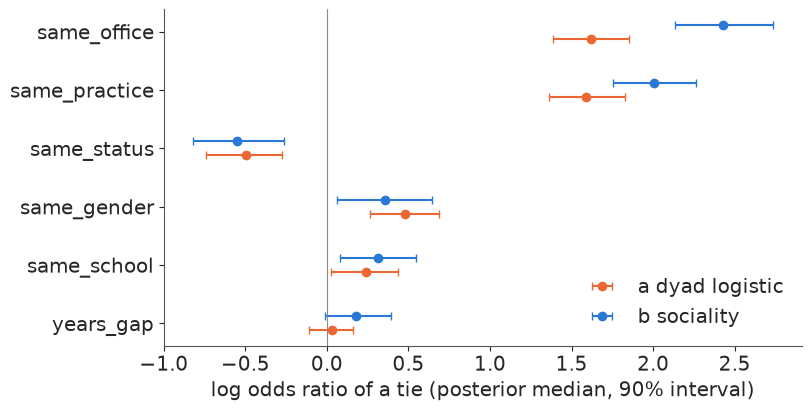

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
for k, (name, col, off) in enumerate([("a dyad logistic", ORANGE, 0.12), ("b sociality", BLUE, -0.12)]):
    b = draws(fits[name], "beta")
    lo, mid, hi = np.quantile(b, [0.05, 0.5, 0.95], axis=0)
    ax.errorbar(mid, np.arange(len(cov_names)) + off, xerr=[mid - lo, hi - mid], fmt="o", color=col,
                capsize=3, label=name)
ax.axvline(0, color=GREY, lw=0.8)
ax.set_yticks(range(len(cov_names)))
ax.set_yticklabels(cov_names)
ax.invert_yaxis()
ax.set(xlabel="log odds ratio of a tie (posterior median, 90% interval)")
ax.legend(loc="lower right");

In [8]:
print(az.summary(fits["b sociality"], var_names=["alpha", "beta", "sigma_s"], round_to=2))

                     mean    sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  \
alpha               -5.14  0.38     -5.77     -4.54    933.53   1244.92   
beta[same_office]    2.43  0.19      2.14      2.73   2259.94   2410.70   
beta[same_practice]  2.01  0.15      1.77      2.25   3042.66   2874.40   
beta[same_status]   -0.55  0.17     -0.81     -0.27   2860.50   2751.51   
beta[same_gender]    0.35  0.18      0.07      0.63   3124.68   2616.29   
beta[same_school]    0.31  0.14      0.08      0.54   7219.76   2374.16   
beta[years_gap]      0.18  0.12     -0.01      0.39   1835.33   2191.27   
sigma_s              0.90  0.10      0.75      1.08   1178.19   1415.13   

                     r_hat  mcse_mean  mcse_sd  
alpha                  1.0       0.01     0.01  
beta[same_office]      1.0       0.00     0.00  
beta[same_practice]    1.0       0.00     0.00  
beta[same_status]      1.0       0.00     0.00  
beta[same_gender]      1.0       0.00     0.00  
beta[same_school]      1.0    

The two models do not merely differ in precision: their 90% intervals for the office effect
**do not overlap**, and those for practice barely touch. Model (a) has been confidently
wrong, in two ways:

- **Attenuation.** Leaving out a node-level random effect in a logistic model shrinks the
  coefficients towards zero (the marginal odds ratio of a mixture of logistic curves is
  flatter than each curve). The busy partners who work with everybody, and the associates
  who work with nobody, dilute the contrast between "same office" and "different office".
- **Pseudo-replication.** Model (a) believes it has 2485 independent observations. The
  information about "how sociable is lawyer 12" enters 70 dyads at once, and the intervals of
  (a) are too narrow because they ignore that.

The sociality sd $\sigma_s \approx 0.9$ says a lawyer one sd above average has
$e^{0.9} \approx 2.5$ times the odds of a tie with anyone, other things equal. Both models
agree on one negative effect: pairs of the same status (two partners or two associates) work
together *less* often than mixed pairs - the firm's work is organised in partner-associate
teams.

## 3 · Latent space (Hoff, Raftery & Handcock 2002)

Model (b) makes a lawyer more or less sociable towards everybody. It cannot say that lawyer
12 works with a *particular* set of people who also work with each other. The latent-space
model gives each lawyer a position $z_i \in \mathbb{R}^2$ and lowers the log odds of a tie by
the distance $\lVert z_i - z_j\rVert$. To see what the latent space learns on its own, fit it
first **without** the covariates: only sociality and positions. If the map recovers offices
and practices, it has found real structure.

In [9]:
fits["c0 latent space, no covariates"] = fit(
    build_logit(I, J, X, y, covariates=False, sociality=True, latent=True),
    "c0 latent, no covariates", ["alpha", "sigma_s", "sigma_z", "z"])

c0 latent, no covariates         6 s   divergences 0   max r_hat 1.509   min bulk ESS 8   (alpha, sigma_s, sigma_z, z)


No divergences, and yet the largest r_hat among the positions is far above 1.01 and the
smallest ESS is a handful of draws. The sampler is fine; the **parameterisation** is not
identified. The likelihood depends on $z$ only through the distances $\lVert z_i - z_j\rVert$,
which are unchanged if the whole configuration is **rotated**, **reflected** or
**translated**. The isotropic prior $z_i \sim N(0, \sigma_z^2 I)$ pins down the translation
(softly) but is itself rotation invariant, so the posterior is a ring of equally good
configurations. Each chain wanders around that ring slowly and chains end up at different
angles or mirror images. This is the continuous cousin of label switching (C06): any quantity
that is a function of the distances is perfectly well estimated.

In [10]:
Zc = fits["c0 latent space, no covariates"].posterior["z"].to_numpy()        # chain, draw, lawyer, dim
chains, ndraw = Zc.shape[:2]
dist_da = xr.DataArray(np.sqrt(((Zc[:, :, I] - Zc[:, :, J]) ** 2).sum(-1)), dims=("chain", "draw", "dyad"))
print(f"max r_hat over the 142 coordinates z:   {float(az.rhat(fits['c0 latent space, no covariates'], var_names=['z'])['z'].max()):.2f}")
print(f"max r_hat over the 2485 distances:      {float(az.rhat(dist_da).max()):.3f}")
print(f"min bulk ESS over the 2485 distances:   {float(az.ess(dist_da).min()):.0f}")

max r_hat over the 142 coordinates z:   1.51


max r_hat over the 2485 distances:      1.007


min bulk ESS over the 2485 distances:   789


### Procrustes post-processing

The standard fix (Hoff et al. 2002) leaves the sampler alone and rotates every draw to a common
reference afterwards. For each draw: centre the configuration (removes translation), then find
the orthogonal matrix $R$ (rotation or reflection) minimising $\lVert Z R - Z_{\text{ref}}\rVert$,
which is $R = UV^\top$ from the SVD $Z^\top Z_{\text{ref}} = U S V^\top$. Using the posterior mean
of the aligned draws as the next reference and repeating a few times (generalised Procrustes
analysis) makes the result independent of which draw started it. The alternative - constraining
the sampler, e.g. fixing one lawyer at the origin and another on the positive x-axis - breaks the
symmetry but makes the fixed lawyers look artificially certain and can create awkward geometry.

after Procrustes: max r_hat 1.005, min bulk ESS 840


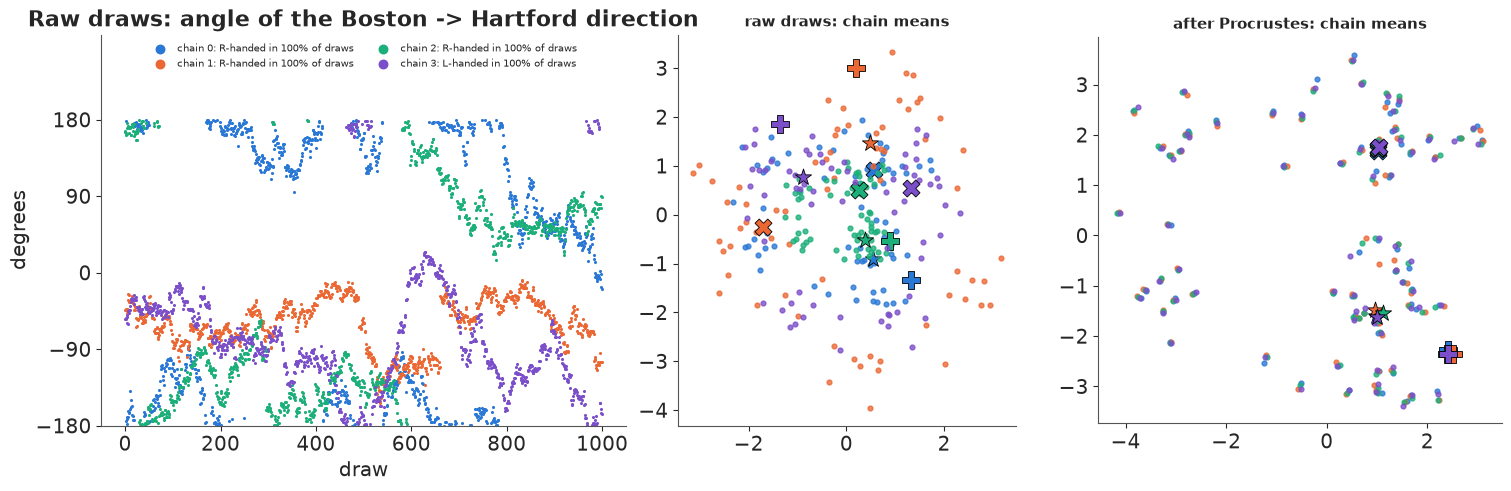

In [11]:
def procrustes(Z, iters=10):
    """Align draws Z (samples, nodes, 2) up to rotation, reflection and translation."""
    Z = Z - Z.mean(1, keepdims=True)
    ref = Z[0]
    for _ in range(iters):
        U, _, Vt = np.linalg.svd(np.einsum("snd,ne->sde", Z, ref))
        R = U @ Vt                                               # (samples, 2, 2) orthogonal
        Za = np.einsum("snd,sde->sne", Z, R)
        ref = Za.mean(0)
    return Za


Za = procrustes(Zc.reshape(chains * ndraw, n, 2)).reshape(chains, ndraw, n, 2)
za_da = xr.DataArray(Za, dims=("chain", "draw", "lawyer", "dim"))
print(f"after Procrustes: max r_hat {float(az.rhat(za_da).max()):.3f}, min bulk ESS {float(az.ess(za_da).min()):.0f}")

hart = att.office.to_numpy() == 2
bos_lit = (att.office.to_numpy() == 1) & (att.practice.to_numpy() == 1)
bos_cor = (att.office.to_numpy() == 1) & (att.practice.to_numpy() == 2)


def orientation(Z):
    """Angle of the Boston -> Hartford direction, and the side on which Boston corporate lies."""
    v = Z[..., hart, :].mean(-2) - Z[..., ~hart, :].mean(-2)
    w = Z[..., bos_cor, :].mean(-2) - Z[..., bos_lit, :].mean(-2)
    return np.degrees(np.arctan2(v[..., 1], v[..., 0])), np.sign(v[..., 0] * w[..., 1] - v[..., 1] * w[..., 0])


chain_cols = [BLUE, ORANGE, AQUA, PURPLE]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), width_ratios=[1.3, 1, 1])
ang, hand = orientation(Zc)
for c in range(chains):
    axes[0].scatter(np.arange(ndraw), ang[c], color=chain_cols[c], s=1.5,
                    label=f"chain {c}: {'L' if np.mean(hand[c]) > 0 else 'R'}-handed in "
                          f"{100 * max(np.mean(hand[c] > 0), np.mean(hand[c] < 0)):.0f}% of draws")
axes[0].set(xlabel="draw", ylabel="degrees", ylim=(-180, 280), yticks=[-180, -90, 0, 90, 180],
            title="Raw draws: angle of the Boston -> Hartford direction")
axes[0].legend(fontsize=7, loc="upper center", ncols=2, markerscale=5)
for ax, Zshow, title in [(axes[1], Zc, "raw draws: chain means"), (axes[2], Za, "after Procrustes: chain means")]:
    for c in range(chains):
        m = Zshow[c].mean(0)
        ax.scatter(m[:, 0], m[:, 1], s=12, color=chain_cols[c], alpha=0.8)
        for lawyer, mk in [(0, "*"), (26, "P"), (41, "X")]:   # three lawyers, to follow by eye
            ax.scatter(*m[lawyer], s=150, marker=mk, color=chain_cols[c], edgecolor="k", lw=0.6)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=11);

Left: the direction from the Boston lawyers' centroid to the Hartford centroid, draw by draw.
Within each chain the configuration **rotates** - a slow random walk that covers a large part
of the circle in 1000 draws - so the chains disagree about the angle and r_hat flags it. The legend records the **handedness** (on which side of the
Boston -> Hartford line the Boston corporate lawyers sit): it never changes within a chain,
because a reflection cannot be reached by a continuous path, so each chain picks one mirror
image at random at the start (the legend shows which). Middle: averaging such draws gives a blurred cloud shrunk towards the origin, and three
lawyers picked out by big symbols land in different places in each chain. Right: after
Procrustes alignment the four chains agree to within the size of the markers, and r_hat on the
aligned coordinates is back near 1.

### The latent map

Now the positions can be plotted with honest uncertainty: a 50% posterior ellipse per lawyer
from the aligned draws, colour for office, marker for practice, and faint lines for the
observed ties.

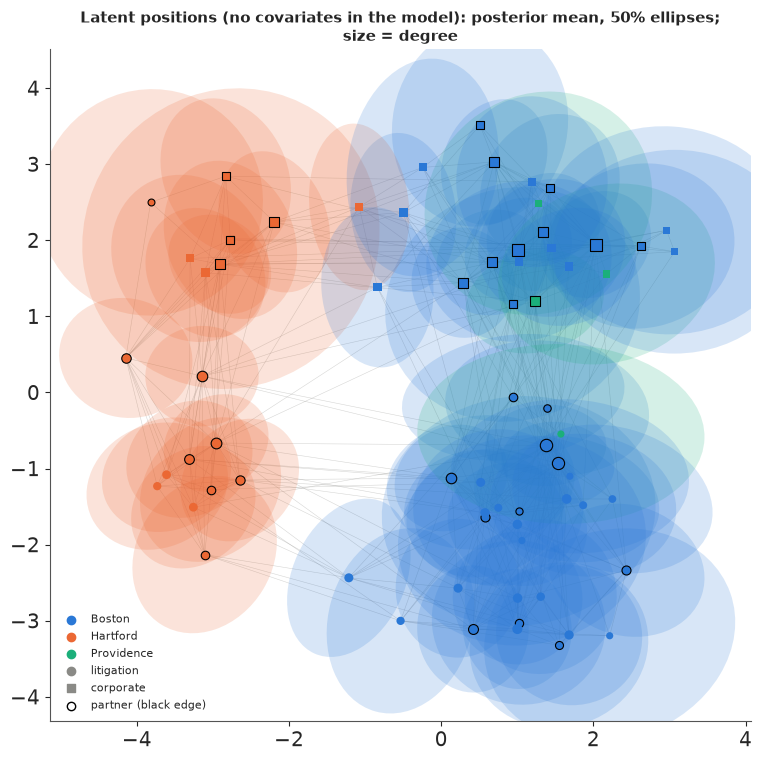

In [12]:
def ellipse(ax, pts, color, q=0.5):
    """Normal-theory ellipse holding a fraction q of the draws `pts` (samples, 2)."""
    mu, cov = pts.mean(0), np.cov(pts.T)
    vals, vecs = np.linalg.eigh(cov)
    r = np.sqrt(sps.chi2(2).ppf(q) * vals)
    ang = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
    ax.add_patch(Ellipse(mu, 2 * r[1], 2 * r[0], angle=ang, color=color, alpha=0.18, lw=0))


office_col = {"Boston": BLUE, "Hartford": ORANGE, "Providence": AQUA}
practice_mk = {"litigation": "o", "corporate": "s"}
Zflat = Za.reshape(-1, n, 2)
zbar = Zflat.mean(0)
fig, ax = plt.subplots(figsize=(8.5, 7.5))
for i, j in zip(I[y == 1], J[y == 1]):
    ax.plot(*zbar[[i, j]].T, color=GREY, lw=0.4, alpha=0.35, zorder=0)
for i in np.flatnonzero(deg > 0):
    col = office_col[att.office_name[i]]
    ellipse(ax, Zflat[:, i], col)
    ax.scatter(*zbar[i], s=18 + 2.2 * deg[i], color=col, marker=practice_mk[att.practice_name[i]],
               edgecolor="k" if att.status[i] == 1 else "none", lw=0.8, zorder=2)
for name, col in office_col.items():
    ax.scatter([], [], color=col, label=name)
for name, mk in practice_mk.items():
    ax.scatter([], [], marker=mk, color=GREY, label=name)
ax.scatter([], [], color="w", edgecolor="k", label="partner (black edge)")
conn = deg > 0                                  # the isolate's position is just its prior: leave it out
ax.set(xlim=(zbar[conn, 0].min() - 1, zbar[conn, 0].max() + 1), ylim=(zbar[conn, 1].min() - 1, zbar[conn, 1].max() + 1))
ax.set_aspect("equal")
ax.legend(fontsize=8, loc="best")
ax.set_title("Latent positions (no covariates in the model): posterior mean, 50% ellipses;\n"
             "size = degree", fontsize=11);

The model was told nothing about offices or practices, yet the map separates them: Hartford
(orange) and Boston (blue) sit on opposite sides, and within *both* offices the litigators
(circles) and the corporate lawyers (squares) are split along the other axis. The few
Providence lawyers (green) sit with the Boston lawyers of their practice. (The orientation is
arbitrary - it is whatever the Procrustes reference happened to be.) The one isolate is left
out: with no ties its position is just its prior. How *much* a lawyer works is carried by the
sociality term $s_i$, which leaves the positions free to encode *with whom*.

### Latent space on top of the covariates

With the covariates back in, the latent space only has to explain what office, practice and
the rest leave unexplained. How much is that?

In [13]:
fits["c latent space"] = fit(build_logit(I, J, X, y, sociality=True, latent=True),
                             "c latent space", ["alpha", "beta", "sigma_s", "sigma_z"])
print(az.summary(fits["c latent space"], var_names=["beta", "sigma_s", "sigma_z"], round_to=2))
print("sigma_z without covariates:", az.summary(fits["c0 latent space, no covariates"],
                                               var_names=["sigma_z"], round_to=2)[["mean", "sd"]].to_numpy())

c latent space                   8 s   divergences 0   max r_hat 1.015   min bulk ESS 221   (alpha, beta, sigma_s, sigma_z)
                     mean    sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  \
beta[same_office]    2.54  0.21      2.21      2.87   1495.43   2168.58   
beta[same_practice]  2.08  0.17      1.81      2.36   2017.51   2370.01   
beta[same_status]   -0.59  0.19     -0.88     -0.29   1570.76   2273.98   
beta[same_gender]    0.38  0.19      0.08      0.69   2331.05   2419.44   
beta[same_school]    0.33  0.15      0.09      0.56   4509.90   3051.69   
beta[years_gap]      0.21  0.13      0.00      0.43   1477.85   1787.65   
sigma_s              0.90  0.12      0.73      1.10   1184.28   1718.02   
sigma_z              0.88  0.29      0.36      1.31    221.32    283.97   

                     r_hat  mcse_mean  mcse_sd  
beta[same_office]     1.00       0.01     0.00  
beta[same_practice]   1.00       0.00     0.00  
beta[same_status]     1.00       0.00     0.00  
beta

The latent scale $\sigma_z$ drops from about 2.3 to about 0.9 once office and practice are in
the model, and its posterior is wide and slow to mix (an ESS in the low hundreds): most of
what the map found on its own *is* office and practice, and what is left is a weak signal.
The homophily coefficients stay close to those of model (b), so the latent space is not
competing with them for the same information.

## 4 · Stochastic block models

A block model assigns every lawyer to one of $K$ unobserved groups $g_i$ and gives each pair
of groups its own tie log odds $B_{kl}$. It is the network analogue of a mixture model - and
here the analogy with C06 breaks down. In a mixture of independent observations, the
discrete labels can be summed out one observation at a time. In a network, $g_i$ appears in
all 70 dyads of lawyer $i$, so the dyads do not factorise over nodes: summing the labels out
exactly means summing over all $K^{71}$ joint assignments ($3^{71} \approx 7 \times 10^{33}$).
The options are Gibbs sampling of the labels (PyMC can do it, but a discrete variable means
no nutpie and a slow `CompoundStep`), a variational approximation, or changing the model.

The **mixed-membership SBM** (Airoldi et al. 2008) changes the model in a way that restores
exact marginalisation. Each lawyer has a membership vector $\pi_i$ on the simplex; for *each
dyad* $i$ draws a role $k \sim \pi_i$ and $j$ a role $l \sim \pi_j$, and the tie is Bernoulli
with log odds $B_{kl}$ (plus, for the **degree-corrected** version, $s_i + s_j$). The roles are
now per dyad, so they sum out dyad by dyad:

$$\log p(y_{ij}) = \operatorname{logsumexp}_{k,l}\left[\log\pi_{ik} + \log\pi_{jl} + \log\text{Bernoulli}(y_{ij} \mid \operatorname{logit}^{-1}(B_{kl} + s_i + s_j))\right]$$

which is a $2485 \times K \times K$ tensor: tiny for $K = 3$. A Dirichlet(0.5) prior on $\pi_i$
prefers memberships near a corner of the simplex, so the model can behave like a hard SBM when
the data say so. The block matrix $B$ is symmetric with $N(-2, 2)$ entries.

In [14]:
def build_mmsb(Ii, Ji, yi, K=3, degree_corrected=True, conc=0.5):
    iu = np.triu_indices(K)
    with pm.Model(coords={**coords, "block": np.arange(K), "block_": np.arange(K)}) as m:
        pi = pm.Dirichlet("pi", a=np.full(K, conc), dims=("lawyer", "block"))
        b_u = pm.Normal("b_u", -2, 2, shape=len(iu[0]))
        Bu = pt.zeros((K, K))[iu].set(b_u)
        B = pm.Deterministic("B", Bu + pt.triu(Bu, 1).T, dims=("block", "block_"))
        eta = pt.broadcast_to(B[None], (len(Ii), K, K))
        if degree_corrected:
            sigma_s = pm.HalfNormal("sigma_s", 1)
            s = pm.Deterministic("s", sigma_s * pm.ZeroSumNormal("s_raw", 1, dims="lawyer"), dims="lawyer")
            eta = eta + (s[Ii] + s[Ji])[:, None, None]
        yy = yi[:, None, None]
        loglik = -yy * pt.softplus(-eta) - (1 - yy) * pt.softplus(eta)     # log Bernoulli(y | eta)
        logpi = pt.log(pi)
        lp = pm.math.logsumexp(logpi[Ii][:, :, None] + logpi[Ji][:, None, :] + loglik, axis=(1, 2))
        pm.Potential("y_marginal", lp.sum())
    return m


def eta_mmsb_prob(post, Ii, Ji, chunk=250):
    """Marginal tie probability sum_kl pi_ik pi_jl expit(B_kl + s_i + s_j), in chunks of draws."""
    out = np.empty((len(post["B"]), len(Ii)))
    for a in range(0, len(out), chunk):
        sl = slice(a, a + chunk)
        eta = post["B"][sl][:, None] + (0 if "s" not in post else (post["s"][sl][:, Ii] + post["s"][sl][:, Ji])[..., None, None])
        w = post["pi"][sl][:, Ii][..., :, None] * post["pi"][sl][:, Ji][..., None, :]
        out[sl] = (w * expit(eta)).sum((-1, -2))
    return out


fits["d0 MMSB, no degree correction"] = fit(build_mmsb(I, J, y, degree_corrected=False),
                                            "d0 MMSB, no degree corr.", ["B", "pi"])
fits["d MMSB, degree-corrected"] = fit(build_mmsb(I, J, y), "d MMSB, degree-corrected", ["B", "sigma_s", "pi"])

d0 MMSB, no degree corr.        18 s   divergences 0   max r_hat 1.844   min bulk ESS 6   (B, pi)


d MMSB, degree-corrected        47 s   divergences 0   max r_hat 1.934   min bulk ESS 6   (B, sigma_s, pi)


Again no divergences and terrible r_hat on $\pi$ and $B$: **label switching**. Block "0" in one
chain is block "2" in another; the likelihood is invariant to permuting the labels. As in
C06, the fix is not to fight the sampler but to report label-invariant quantities. The
natural one for a block model is the **co-clustering matrix** $C_{ij} = \pi_i^\top \pi_j$: the
probability that $i$ and $j$ play the same role in a random interaction (for a hard SBM, the
posterior probability that they are in the same block). It does not care what the blocks are
called.

In [15]:
def coclustering(idata):
    P = idata.posterior["pi"].to_numpy()
    return np.einsum("cdik,cdjk->cdij", P, P)


for name in ["d0 MMSB, no degree correction", "d MMSB, degree-corrected"]:
    C = coclustering(fits[name])
    rh = float(az.rhat(xr.DataArray(C[:, :, I, J], dims=("chain", "draw", "dyad"))).max())
    rp = float(az.rhat(fits[name], var_names=["pi"])["pi"].max())
    print(f"{name:<32} max r_hat: pi {rp:.2f}   co-clustering {rh:.3f}")

d0 MMSB, no degree correction    max r_hat: pi 1.84   co-clustering 1.004


d MMSB, degree-corrected         max r_hat: pi 1.93   co-clustering 1.185


For the plain block model the label-invariant summary is healthy: the chains found the same
partition under different names. For the degree-corrected model it is not, so something
other than label switching is going on. The sampler's log density per draw (`logp` in
`sample_stats`) is label-invariant too, and it tells the story.

degree-corrected MMSB, default warm-up (400): mean logp per chain, first half [-1221.  -1208.  -1181.4 -1180.7], second half [-1183.7 -1182.7 -1182.5 -1182. ]


d MMSB, degree-corr., tune=1000    62 s   divergences 0   max r_hat 1.941   min bulk ESS 6   (B, sigma_s, pi)
degree-corrected MMSB, tune=1000: mean logp per chain, first half [-1181.3 -1184.6 -1182.4 -1182.7], second half [-1182.8 -1181.8 -1183.6 -1183.1]


tune=1000: max r_hat co-clustering 1.005


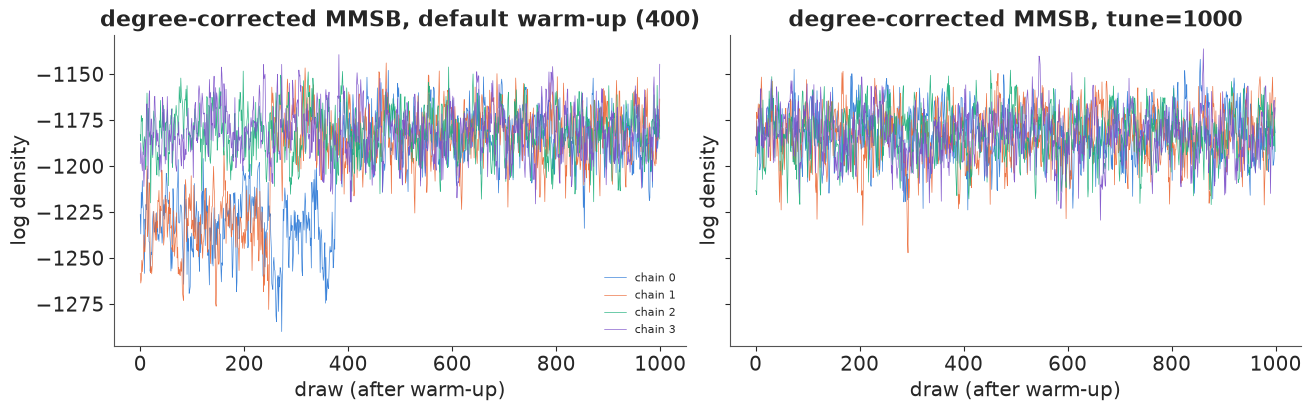

In [16]:
def logp_trace(idata, ax, title):
    lp = idata.sample_stats["logp"].to_numpy()
    for c in range(lp.shape[0]):
        ax.plot(lp[c], color=chain_cols[c], lw=0.5, alpha=0.9, label=f"chain {c}")
    half = lp.shape[1] // 2
    print(f"{title}: mean logp per chain, first half {lp[:, :half].mean(1).round(1)}, "
          f"second half {lp[:, half:].mean(1).round(1)}")
    ax.set(xlabel="draw (after warm-up)", ylabel="log density", title=title)


fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
logp_trace(fits["d MMSB, degree-corrected"], axes[0], "degree-corrected MMSB, default warm-up (400)")
fits["d MMSB, degree-corrected"] = fit(build_mmsb(I, J, y), "d MMSB, degree-corr., tune=1000",
                                       ["B", "sigma_s", "pi"], tune=1000)
logp_trace(fits["d MMSB, degree-corrected"], axes[1], "degree-corrected MMSB, tune=1000")
C = coclustering(fits["d MMSB, degree-corrected"])
print(f"tune=1000: max r_hat co-clustering "
      f"{float(az.rhat(xr.DataArray(C[:, :, I, J], dims=('chain', 'draw', 'dyad'))).max()):.3f}")
axes[0].legend(fontsize=8);

With nutpie's default 400 warm-up steps, two of the four chains spent the first few hundred
*kept* draws at a log density some 40-60 units below the others before jumping up to the same
level: they were still converging when warm-up ended. The co-clustering r_hat of about 1.19
was measuring that, not label switching. With 1000 warm-up steps every chain starts at the
typical set and the co-clustering r_hat drops to about 1.005, while r_hat on $\pi$ stays
near 2 - as it should, since that part *is* label switching. Two lessons: a label-invariant
r_hat separates "the chains disagree about names" from "the chains disagree about the
answer", and a mixture-type posterior (flat directions, Dirichlet simplices, $K!$ modes) may
need a longer warm-up than the default. The refit replaces the first one from here on.

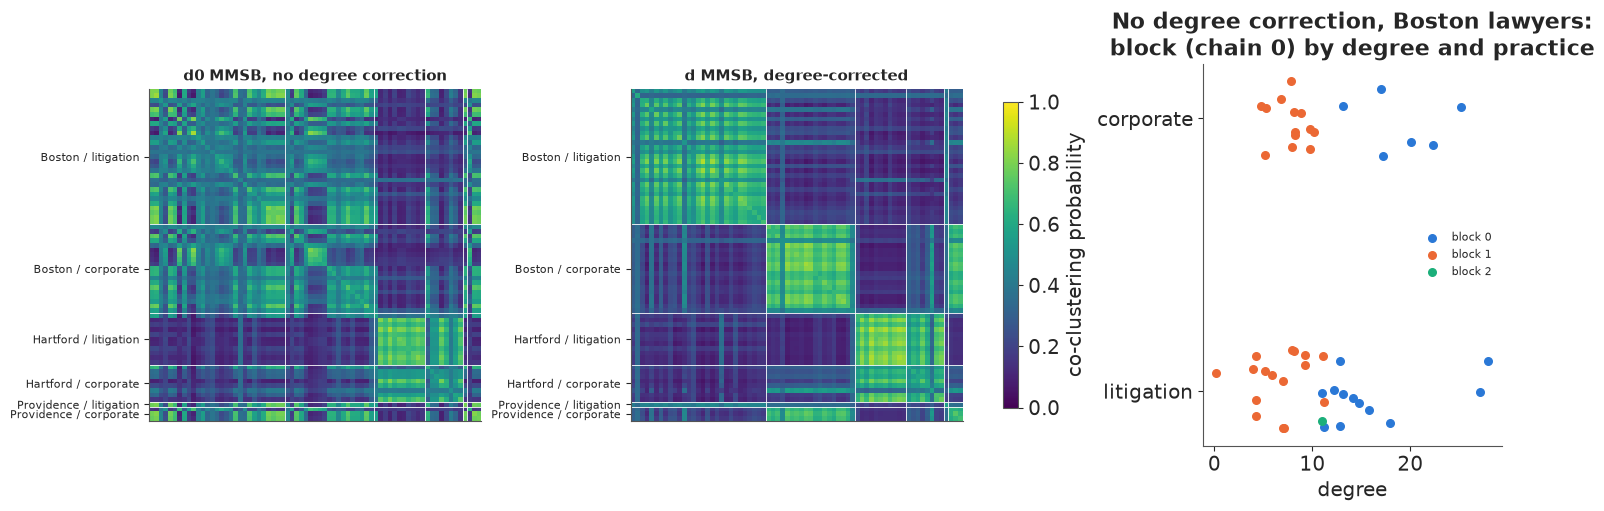

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), width_ratios=[1, 1, 0.9])
for ax, name in zip(axes[:2], ["d0 MMSB, no degree correction", "d MMSB, degree-corrected"]):
    C = coclustering(fits[name]).mean((0, 1))
    im = ax.imshow(C[np.ix_(order, order)], cmap="viridis", vmin=0, vmax=1)
    for c in cuts:
        ax.axhline(c, color="w", lw=0.6)
        ax.axvline(c, color="w", lw=0.6)
    ax.set_yticks((starts + ends - 1) / 2)
    ax.set_yticklabels([grp[s] for s in starts], fontsize=8)
    ax.set_xticks([])
    ax.set_title(name, fontsize=11)
fig.colorbar(im, ax=axes[:2], shrink=0.8, label="co-clustering probability")
ax = axes[2]
pi0 = fits["d0 MMSB, no degree correction"].posterior["pi"].sel(chain=0).mean("draw").to_numpy()
hard0 = pi0.argmax(1)
boston = att.office.to_numpy() == 1
for k, col in zip(range(3), [BLUE, ORANGE, AQUA]):
    sel = (hard0 == k) & boston
    ax.scatter(deg[sel] + rng.uniform(-0.3, 0.3, sel.sum()),
               att.practice.to_numpy()[sel] + rng.uniform(-0.15, 0.15, sel.sum()),
               color=col, s=30, label=f"block {k}")
ax.set_yticks([1, 2])
ax.set_yticklabels(["litigation", "corporate"])
ax.set(xlabel="degree", title="No degree correction, Boston lawyers:\nblock (chain 0) by degree and practice")
ax.legend(fontsize=8);

The two block models find different structure in the same data.

- **Without degree correction** (left, and right panel for the Boston lawyers) the blocks
  cut across practice: the model separates the Boston lawyers largely by *how many* ties they
  have, into a well-connected core and a sparse periphery, because in a plain SBM all members
  of a block must have the same expected degree. A lawyer with 25 coworkers and one with 3
  are pushed into different blocks, whatever they have in common. This is the failure that led Karrer and
  Newman (2011) to the degree-corrected SBM.
- **With degree correction** (middle) the sociality terms absorb the degrees, and the three
  blocks become Boston litigation, Boston corporate (with the Providence corporate lawyers) and
  Hartford - the office x practice structure of the firm, found without being told about it.

The same point as section 2, arriving from the other side: degree heterogeneity is not a
nuisance detail - leave it out and it hijacks whatever other latent structure you give the
model.

## 5 · Posterior predictive checks on the whole graph

A model of a network should produce networks that look like the observed one. From 200
posterior draws of each model we simulate 200 graphs (one per draw) and compute the
statistics of section 1 on each. The dyad-level tie probabilities are computed in NumPy from
the posterior draws, for every model, by the same functions used for link prediction later.

In [18]:
def tie_prob(idata, Ii, Ji, Xi, thin=1):
    post = {v: draws(idata, v)[::thin] for v in ["alpha", "beta", "s", "z", "B", "pi"]
            if v in idata.posterior}
    if "pi" in post:
        return eta_mmsb_prob(post, Ii, Ji)
    return expit(eta_logit(post, Ii, Ji, Xi))


def simulate_graph(p):
    M = np.zeros((n, n))
    M[I, J] = rng.random(len(p)) < p
    return M + M.T


model_names = list(fits)
ppc = {}
for name in model_names:
    P = tie_prob(fits[name], I, J, X, thin=20)                      # 200 draws x 2485 dyads
    sims = [simulate_graph(p) for p in P]
    ppc[name] = {"stats": pd.DataFrame([graph_stats(M) for M in sims]),
                 "esp": np.array([esp_hist(M) for M in sims]),
                 "geo": np.array([geo_hist(M) for M in sims]),
                 "deg": np.sort(np.array([M.sum(1) for M in sims]), axis=1)[:, ::-1]}

rows = {}
for name in model_names:
    st = ppc[name]["stats"]
    esp0 = ppc[name]["esp"][:, 0]
    rows[name] = {**{k: f"{st[k].quantile(0.05):.2f} - {st[k].quantile(0.95):.2f}"
                     for k in ["sd degree", "transitivity", "mean geodesic"]},
                  "P(transitivity_rep >= obs)": f"{(st['transitivity'] >= obs_stats['transitivity']).mean():.2f}",
                  "ties, 0 shared partners": f"{np.quantile(esp0, 0.05):.0f} - {np.quantile(esp0, 0.95):.0f}",
                  "P(esp0_rep <= obs)": f"{(esp0 <= obs_esp[0]).mean():.2f}",
                  "isolates (mean)": f"{st['isolates'].mean():.2f}"}
rows["OBSERVED"] = {"sd degree": f"{obs_stats['sd degree']:.2f}", "transitivity": f"{obs_stats['transitivity']:.2f}",
                    "mean geodesic": f"{obs_stats['mean geodesic']:.2f}", "ties, 0 shared partners": f"{obs_esp[0]}",
                    "isolates (mean)": f"{obs_stats['isolates']}"}
pd.DataFrame(rows).T.fillna("")

,sd degree,transitivity,mean geodesic,P(transitivity_rep >= obs),"ties, 0 shared partners",P(esp0_rep <= obs),isolates (mean)
a0 Erdos-Renyi,2.54 - 3.34,0.13 - 0.17,1.94 - 2.10,0.00,54 - 97,0.00,0.00
a dyad logistic,3.43 - 4.64,0.19 - 0.26,2.03 - 2.21,0.00,39 - 71,0.00,0.04
b sociality,5.29 - 6.70,0.26 - 0.32,2.02 - 2.19,0.15,15 - 36,0.02,0.32
"c0 latent space, no covariates",5.26 - 6.56,0.27 - 0.34,2.05 - 2.22,0.64,14 - 31,0.04,0.56
c latent space,5.23 - 6.75,0.26 - 0.33,2.04 - 2.19,0.24,13 - 34,0.04,0.33
"d0 MMSB, no degree correction",4.28 - 5.77,0.20 - 0.26,1.99 - 2.12,0.00,27 - 61,0.00,0.10
"d MMSB, degree-corrected",5.21 - 6.63,0.24 - 0.30,1.98 - 2.12,0.03,18 - 41,0.01,0.33
OBSERVED,5.74,0.31,2.10,,12,,1


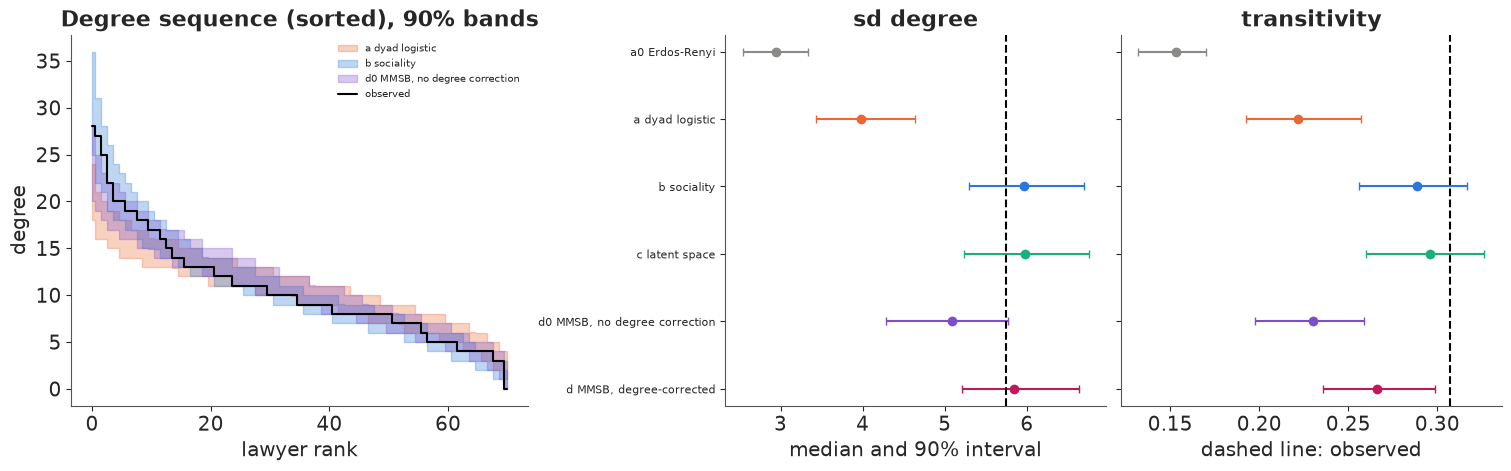

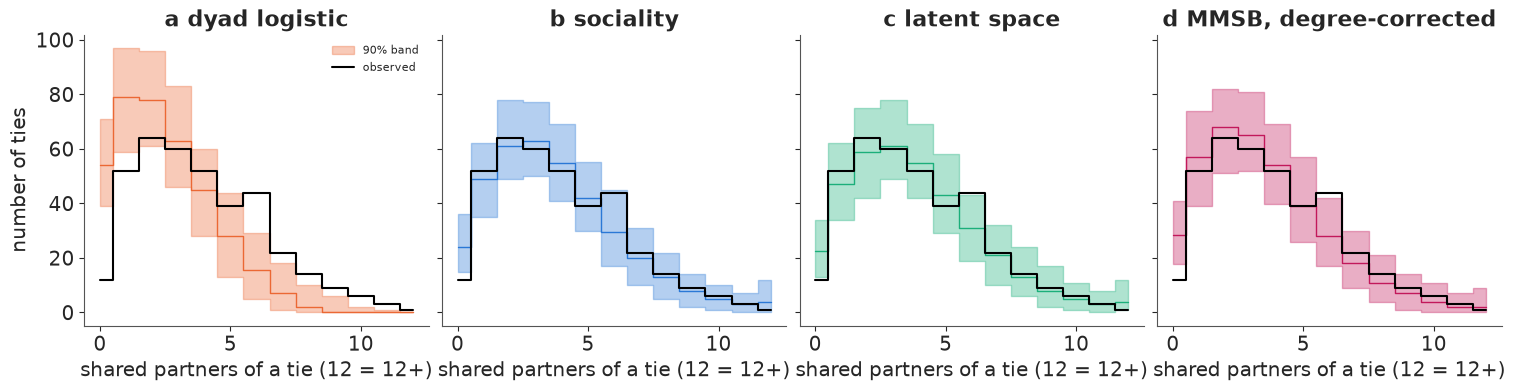

In [19]:
show = ["a0 Erdos-Renyi", "a dyad logistic", "b sociality", "c latent space", "d0 MMSB, no degree correction",
        "d MMSB, degree-corrected"]
cols = [GREY, ORANGE, BLUE, AQUA, PURPLE, RED]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), width_ratios=[1.2, 1, 1])
ax = axes[0]
for name, col in zip(show[1:3] + show[4:5], cols[1:3] + cols[4:5]):
    lo, hi = np.quantile(ppc[name]["deg"], [0.05, 0.95], axis=0)
    ax.fill_between(np.arange(n), lo, hi, color=col, alpha=0.3, step="mid", label=name)
ax.step(np.arange(n), np.sort(deg)[::-1], color="k", where="mid", label="observed")
ax.set(xlabel="lawyer rank", ylabel="degree", title="Degree sequence (sorted), 90% bands")
ax.legend(fontsize=7)
for ax, stat in zip(axes[1:], ["sd degree", "transitivity"]):
    for k, (name, col) in enumerate(zip(show, cols)):
        v = ppc[name]["stats"][stat]
        lo, mid, hi = v.quantile([0.05, 0.5, 0.95])
        ax.errorbar(mid, k, xerr=[[mid - lo], [hi - mid]], fmt="o", color=col, capsize=3)
    ax.axvline(obs_stats[stat], color="k", ls="--", label="observed")
    ax.set_yticks(range(len(show)))
    ax.set_yticklabels(show if stat == "sd degree" else [], fontsize=8)
    ax.invert_yaxis()
    ax.set(title=stat, xlabel="median and 90% interval" if stat == "sd degree" else "dashed line: observed")

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
xs = np.arange(len(obs_esp))
for ax, name, col in zip(axes, show[1:4] + show[5:], cols[1:4] + cols[5:]):
    lo, mid, hi = np.quantile(ppc[name]["esp"], [0.05, 0.5, 0.95], axis=0)
    ax.fill_between(xs, lo, hi, color=col, alpha=0.35, step="mid", label="90% band")
    ax.step(xs, mid, color=col, where="mid", lw=1)
    ax.step(xs, obs_esp, color="k", where="mid", label="observed")
    ax.set(xlabel="shared partners of a tie (12 = 12+)", title=name)
axes[0].set_ylabel("number of ties")
axes[0].legend(fontsize=8);

Reading the table and the two figures together:

- **Degrees.** Erdős-Rényi and the covariate-only model (a) produce degree distributions far
  too narrow (sd 2.5-4.6 against 5.7): homophily alone does not make some lawyers busier than
  others. Every model with a sociality term reproduces the spread. The plain block model (d0)
  gets part of the way by turning degree into block membership.
- **Transitivity.** Independent ties give 0.15; homophily on observed attributes raises it to
  about 0.22, and sociality combined with covariates or a latent space gets to 0.26-0.34,
  covering the observed 0.31. The latent-space model without covariates is
  the one that puts the observed value in the middle of its predictive distribution
  (posterior predictive p about 0.6); the degree-corrected block model is on the low side
  (p about 0.03) - presumably three blocks are too coarse for the smaller teams inside them.
- **Shared partners.** The sharpest check. Only 12 of the 378 ties join two lawyers with *no*
  coworker in common. Every model predicts more such "isolated" ties (the best, the two latent
  space models and model (b), predict 13-36), so the observed count sits at the edge of their
  distributions (p = 0.02-0.04). The ESP panels show the covariate-only model putting too many
  ties at 0-2 shared partners and too few at 5-10; with sociality or a latent space the whole
  distribution fits except that bottom bin. Real collaboration is more *closed* than any of
  these conditionally-independent-dyad models quite manage: the classic motivation for ERGMs
  with a geometrically weighted shared-partner term (Snijders et al. 2006 used exactly this
  network).

The geodesic distribution tells the same story from the other end: how many pairs are one,
two, three or more steps apart.

In [20]:
geo_rows = {name: ppc[name]["geo"].mean(0) for name in show}
geo_rows["OBSERVED"] = obs_geo
pd.DataFrame(geo_rows, index=["1", "2", "3", "4", "5+ or unreachable"]).T.round(3)

,1,2,3,4,5+ or unreachable
a0 Erdos-Renyi,0.152,0.679,0.168,0.000,0.000
a dyad logistic,0.152,0.595,0.244,0.007,0.001
b sociality,0.152,0.595,0.234,0.009,0.009
c latent space,0.152,0.588,0.241,0.009,0.010
"d0 MMSB, no degree correction",0.156,0.638,0.200,0.003,0.003
"d MMSB, degree-corrected",0.157,0.631,0.199,0.004,0.009
OBSERVED,0.152,0.573,0.241,0.006,0.028


Erdős-Rényi puts too many pairs at distance 2 and too few at 3: random graphs are "small
worlds" where everybody is two steps from everybody. The homophily models push pairs from
different offices and practices further apart and match the distance-3 share (0.24); the
block models without covariates stop at 0.20. No model reproduces the 2.8% of unreachable
pairs, which all come from the single isolate (its 70 pairs): the "isolates" column of the
table above shows that the simulated graphs contain between 0 and 0.6 isolates on average,
against one observed.

## 6 · Which model predicts ties it has not seen?

PPCs check whether a model *can* reproduce a feature of the data; they do not penalise a model
for flexibility. Two ways to score prediction:

1. **Leave-one-dyad-out** with PSIS-LOO on the full-data fits: the log predictive density of
   each dyad given all the others. For the mixed-membership model the pointwise log
   likelihood is the marginal $\log p(y_{ij})$ from the `logsumexp`, which we compute in NumPy
   and attach as a `log_likelihood` group - `az.loo` does not care where it came from.
2. **A held-out set**: hide a random 20% of the dyads (ties *and* non-ties), refit every model on
   the other 80%, and score the hidden ones with the area under the ROC curve (AUC: the
   probability that a random hidden tie gets a higher predicted probability than a random
   hidden non-tie) and the mean log predictive density.

Both are legitimate for "is this pair of lawyers likely to work together?" - a missing-data
question. Neither is a test of predicting the ties of a *new lawyer*, which would need
leave-one-node-out.

In [21]:
def attach_loglik(idata, p):
    """Add a log_likelihood group built from tie probabilities p (samples, dyads)."""
    ll = np.where(y == 1, np.log(p), np.log1p(-p)).reshape(idata.posterior.sizes["chain"],
                                                           idata.posterior.sizes["draw"], -1)
    return xr.DataTree.from_dict({"posterior": idata.posterior.to_dataset(),
                                  "log_likelihood": xr.Dataset({"y": (("chain", "draw", "dyad"), ll)})})


loo = {}
for name in model_names:
    p = np.clip(tie_prob(fits[name], I, J, X), 1e-12, 1 - 1e-12)
    loo[name] = az.loo(attach_loglik(fits[name], p))
    loo[name].log_weights = None                                 # keep only the summary (memory)
    del p
az.compare(loo, round_to=1)

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
c latent space,0,0.0,0.0,NaN,,,124.6,-761.6,28.6,0.3
b sociality,1,-1.8,2.4,0.8,|elpd_diff| < 4,,60.7,-763.4,28.5,0.4
"c0 latent space, no covariates",2,-34.1,13.4,1.0,,13 k̂ > 0.70,182.4,-795.7,29.0,0.3
"d MMSB, degree-corrected",3,-57.3,12.7,1.0,,,104.4,-818.8,26.7,0.0
a dyad logistic,4,-132.6,16.6,1.0,,,6.9,-894.2,29.6,0.0
"d0 MMSB, no degree correction",5,-149.4,16.9,1.0,,,68.9,-911.0,27.8,0.0
a0 Erdos-Renyi,6,-298.9,22.9,1.0,,,1.0,-1060.5,30.8,0.0


Leave-one-dyad-out puts the latent-space model with covariates and the sociality model in a
dead heat (a difference of about 2 elpd with a standard error of about 2.4): the latent
positions buy nothing measurable once the covariates and sociality are in. The latent-space
model without covariates and the degree-corrected block model - both of which had to *find*
the office and practice structure themselves - are far behind the models that were given it,
but far ahead of the covariate-only model (a), which lacks degree heterogeneity. The plain
block model is worse than (a). The no-covariate latent-space model has a dozen or so dyads
with Pareto $\hat k > 0.7$, so its LOO estimate is the least reliable of the set.

Now the held-out split. The same builders are called on the 80% training dyads; the hidden 20%
never enter the likelihood.

In [22]:
test = rng.random(len(y)) < 0.2
tr = ~test
print(f"training dyads {tr.sum()} ({y[tr].sum()} ties), held-out dyads {test.sum()} ({y[test].sum()} ties)")


def auc(p, yt):
    r = rankdata(p)
    n1 = yt.sum()
    return (r[yt == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * (len(yt) - n1))


builders = {
    "a0 Erdos-Renyi": lambda: build_logit(I[tr], J[tr], X[tr], y[tr], covariates=False),
    "a dyad logistic": lambda: build_logit(I[tr], J[tr], X[tr], y[tr]),
    "b sociality": lambda: build_logit(I[tr], J[tr], X[tr], y[tr], sociality=True),
    "c0 latent space, no covariates": lambda: build_logit(I[tr], J[tr], X[tr], y[tr], covariates=False,
                                                          sociality=True, latent=True),
    "c latent space": lambda: build_logit(I[tr], J[tr], X[tr], y[tr], sociality=True, latent=True),
    "d0 MMSB, no degree correction": lambda: build_mmsb(I[tr], J[tr], y[tr], degree_corrected=False),
    "d MMSB, degree-corrected": lambda: build_mmsb(I[tr], J[tr], y[tr]),
}
held = {}
for name, build in builders.items():
    t0 = time.time()
    with build():
        idt = pm.sample(random_seed=RANDOM_SEED, progressbar=False,
                        tune=1000 if "MMSB" in name else None)       # section 4: MMSBs need more warm-up
    p = tie_prob(idt, I[test], J[test], X[test])                # samples x held-out dyads
    yt = y[test]
    lpd = np.log(np.where(yt == 1, p, 1 - p).mean(0))           # log of the posterior-mean probability
    held[name] = {"AUC": auc(p.mean(0), yt), "mean log pred. density": lpd.mean(),
                  "divergences": int(idt.sample_stats["diverging"].sum()), "seconds": time.time() - t0}
    held[name]["_p"] = p.mean(0)
    del idt, p
held_df = pd.DataFrame(held).T.drop(columns="_p")
held_df.astype(float).round(3)

training dyads 1986 (301 ties), held-out dyads 499 (77 ties)


,AUC,mean log pred. density,divergences,seconds
a0 Erdos-Renyi,0.500,-0.430,0.0,0.367
a dyad logistic,0.748,-0.375,0.0,1.851
b sociality,0.843,-0.319,0.0,2.419
"c0 latent space, no covariates",0.829,-0.332,0.0,5.308
c latent space,0.843,-0.318,0.0,5.988
"d0 MMSB, no degree correction",0.727,-0.390,0.0,21.050
"d MMSB, degree-corrected",0.833,-0.338,0.0,42.403


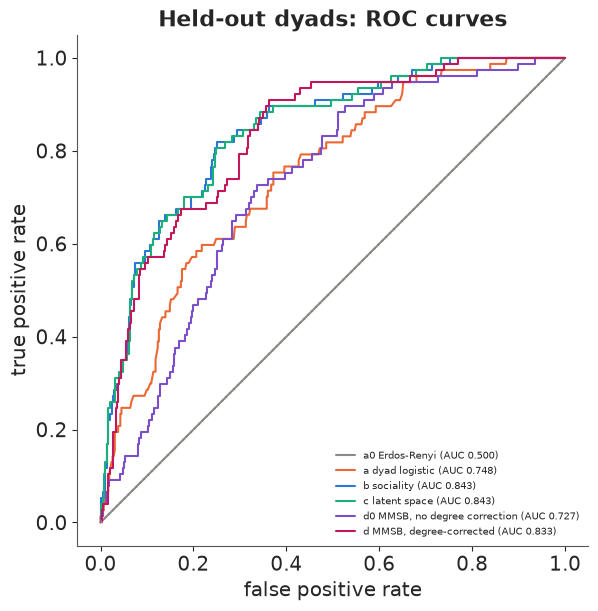

In [23]:
fig, ax = plt.subplots(figsize=(6.5, 6))
yt = y[test]
for name, col in zip(show, cols):
    p = held[name]["_p"]
    thr = np.sort(np.unique(p))[::-1]
    tpr = [(p[yt == 1] >= t).mean() for t in thr]
    fpr = [(p[yt == 0] >= t).mean() for t in thr]
    ax.plot(np.r_[0, fpr], np.r_[0, tpr], color=col, lw=1.5, label=f"{name} (AUC {held[name]['AUC']:.3f})")
ax.plot([0, 1], [0, 1], color=GREY, ls=":")
ax.set(xlabel="false positive rate", ylabel="true positive rate", title="Held-out dyads: ROC curves")
ax.set_aspect("equal")
ax.legend(fontsize=7, loc="lower right");

The held-out split agrees with LOO on the ranking: sociality with covariates and latent space
with covariates are tied (AUC 0.84), the two structure-finding models without covariates
follow closely (0.83), the covariate-only model and the plain block model are well behind
(about 0.73-0.75), and Erdős-Rényi is a coin flip by construction. The ROC curves show where
the difference is made: at a false-positive rate of 30%, the degree-aware models recover
about 85% of the held-out ties, the covariate-only model about 68%. With 77 held-out ties, differences in the third
decimal of the AUC are noise.

The honest summary for this firm: **most of the network is explained by homophily on office
and practice plus degree heterogeneity**. The latent space and the block model are
valuable here as *discovery* tools - they recover the office x practice structure without
being told - and as checks that nothing big is missing, not as better predictors. On a network
without such informative attributes (or with the attributes hidden, as in the `c0` and `d`
rows) they are the only way to get the structure at all.

## 7 · Summary

| Question | Tool |
|---|---|
| Are dyads independent? | No: degrees far more spread than Binomial, transitivity twice the density |
| What does iid dyad regression get wrong? | attenuated homophily effects with overconfident intervals |
| Who is sociable? | sociality random effects $s_i$ ($p_1$ / $p_2$-style) |
| Who works with whom, beyond the covariates? | latent space, plotted after Procrustes alignment |
| What groups are there? | (mixed-membership) SBM with degree correction; co-clustering matrix |
| Did the sampler work? | r_hat on *identified* quantities: distances, co-clustering, tie probabilities |
| Does the model reproduce the graph? | PPC on degree sequence, transitivity, shared partners, geodesics |
| Does it predict missing ties? | dyad-level PSIS-LOO and a held-out split (AUC, log density) |

## Try it yourself

1. **Friendship is directed.** The same zip file holds `ELfriend.dat`, a *directed* friendship
   network (who says they socialise with whom). Register it, and fit a directed $p_2$-style
   model with separate sender and receiver effects, correlated through `pm.LKJCholeskyCov`, and
   a reciprocity term (model the two dyad directions jointly: a dyad is one of four states).
   Is friendship more reciprocal than a sociality model predicts?
2. **How many blocks?** Refit the degree-corrected MMSB with $K = 2, 4, 5$ and compare with
   dyad-level LOO and the held-out AUC. Where does the co-clustering matrix stop changing? Does
   $K = 4$ split Hartford by practice, or partners from associates?
3. **A hard SBM with Gibbs.** Write the plain SBM with a discrete `pm.Categorical` label per
   lawyer (the model PyMC cannot marginalise), sample it with `cores=2` (it will not run under
   nutpie), and compare its co-clustering matrix and run time with the mixed-membership version.
   How well do the chains mix between partitions?